# Operación ChasquiFest — CASO 2: Logística
## Auditoría de visualización e inferencia — Caravana entre 12 sedes

**Auditor:** análisis reproducible sobre `../data/caso2_logistica_chasquifest.csv`
**Granularidad de los datos:** una fila = un envío. n = 1728 envíos, 12 sedes (departamento/macrozona destino), 18 semanas (`semana_inicio` 2026-03-02 a 2026-06-29), 3 transportistas (Apu Express, Río Rápido, Costa Norte), 3 vehículos (Van, Moto, Camión), 3 macrozonas (Costa, Sierra, Selva).

Cada celda de código carga o deriva los números que se citan en el texto — no hay cifras "de memoria": todo número en las respuestas de abajo tiene su celda de cálculo correspondiente arriba.


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)

# Paleta accesible (Okabe-Ito, segura para daltonismo y legible en escala de grises por contraste de luminancia)
OKABE_ITO = {
    'Apu Express': '#0072B2',   # azul
    'Río Rápido':  '#D55E00',   # vermellón
    'Costa Norte': '#009E73',   # verde
    'focal':       '#D55E00',
    'contexto':    '#B0B0B0',   # gris neutro
    'meta':        '#444444',
}

CSV_PATH = '../data/caso2_logistica_chasquifest.csv'
df = pd.read_csv(CSV_PATH, parse_dates=['fecha_envio', 'semana_inicio'])
print('Shape:', df.shape)
print(df.dtypes)
df.head()


Shape: (1728, 17)
envio_id                       str
fecha_envio         datetime64[us]
semana_inicio       datetime64[us]
sede_id                        str
ciudad                         str
departamento                   str
macrozona                      str
transportista                  str
vehiculo                       str
distancia_km               float64
lluvia_flag                  int64
lluvia_mm                  float64
minutos_objetivo           float64
minutos_reales             float64
tardanza_flag                int64
bultos                       int64
costo_soles                float64
dtype: object


,envio_id,fecha_envio,semana_inicio,sede_id,ciudad,departamento,macrozona,transportista,vehiculo,distancia_km,lluvia_flag,lluvia_mm,minutos_objetivo,minutos_reales,tardanza_flag,bultos,costo_soles
0,ENV-00001,2026-03-03,2026-03-02,SED-01,Lima,Lima,Costa,Apu Express,Van,76.4,1,12.0,150.4,213.6,1,22,325.64
1,ENV-00002,2026-03-04,2026-03-02,SED-01,Lima,Lima,Costa,Apu Express,Moto,44.7,0,0.0,101.9,80.9,0,10,186.43
2,ENV-00003,2026-03-03,2026-03-02,SED-01,Lima,Lima,Costa,Río Rápido,Van,34.4,0,0.0,98.0,110.3,1,5,152.38
3,ENV-00004,2026-03-03,2026-03-02,SED-01,Lima,Lima,Costa,Costa Norte,Camión,211.2,0,0.0,355.0,496.7,1,8,480.03
4,ENV-00005,2026-03-08,2026-03-02,SED-01,Lima,Lima,Costa,Apu Express,Van,122.0,0,0.0,207.5,213.6,0,19,353.48


In [2]:
# Sanity check: nulos, sedes, semanas, rango temporal
print('Nulos por columna:\n', df.isna().sum().to_string())
print()
print('N sedes:', df['sede_id'].nunique(), '| N semanas:', df['semana_inicio'].nunique())
print('Rango semana_inicio:', df['semana_inicio'].min().date(), '->', df['semana_inicio'].max().date())
print('Transportistas:', sorted(df['transportista'].unique()))
print('Vehículos:', sorted(df['vehiculo'].unique()))
print('Macrozonas:', sorted(df['macrozona'].unique()))
print()
print('Mapa sede -> departamento -> macrozona:')
print(df[['sede_id','ciudad','departamento','macrozona']].drop_duplicates().sort_values('sede_id').to_string(index=False))


Nulos por columna:
 envio_id            0
fecha_envio         0
semana_inicio       0
sede_id             0
ciudad              0
departamento        0
macrozona           0
transportista       0
vehiculo            0
distancia_km        0
lluvia_flag         0
lluvia_mm           0
minutos_objetivo    0
minutos_reales      0
tardanza_flag       0
bultos              0
costo_soles         0

N sedes: 12 | N semanas: 18
Rango semana_inicio: 2026-03-02 -> 2026-06-29
Transportistas: ['Apu Express', 'Costa Norte', 'Río Rápido']
Vehículos: ['Camión', 'Moto', 'Van']
Macrozonas: ['Costa', 'Selva', 'Sierra']

Mapa sede -> departamento -> macrozona:
sede_id   ciudad departamento macrozona
 SED-01     Lima         Lima     Costa
 SED-02    Piura        Piura     Costa
 SED-03 Trujillo  La Libertad     Costa
 SED-04 Chiclayo   Lambayeque     Costa
 SED-05 Arequipa     Arequipa    Sierra
 SED-06    Cusco        Cusco    Sierra
 SED-07     Puno         Puno    Sierra
 SED-08 Ayacucho     Ayacucho  

In [3]:
# ANCLA 1: tasa de tardanza agregada = SUM(tardanza_flag) / N
n_total = len(df)
n_tarde = int(df['tardanza_flag'].sum())
tasa_tardanza_agregada = n_tarde / n_total
print(f'num (envíos tardíos) = {n_tarde}')
print(f'den (envíos totales) = {n_total}')
print(f'Tasa de tardanza agregada = {n_tarde}/{n_total} = {tasa_tardanza_agregada:.4%}')
print(f'Meta operativa = 20.00%  ->  brecha = {tasa_tardanza_agregada - 0.20:+.4%} ({(tasa_tardanza_agregada/0.20):.2f}x la meta)')


num (envíos tardíos) = 772
den (envíos totales) = 1728
Tasa de tardanza agregada = 772/1728 = 44.6759%
Meta operativa = 20.00%  ->  brecha = +24.6759% (2.23x la meta)


In [4]:
# ANCLA 2: verificación de la regla de tardanza_flag
# Regla propuesta: tardanza_flag = 1 si minutos_reales >= 1.12 * minutos_objetivo
df['ratio_real_objetivo'] = df['minutos_reales'] / df['minutos_objetivo']
df['calc_ge_112'] = (df['minutos_reales'] >= 1.12 * df['minutos_objetivo']).astype(int)
df['calc_gt_112'] = (df['minutos_reales'] >  1.12 * df['minutos_objetivo']).astype(int)

diff_ge = (df['calc_ge_112'] != df['tardanza_flag']).sum()
diff_gt = (df['calc_gt_112'] != df['tardanza_flag']).sum()
print(f'Filas donde (minutos_reales >= 1.12*objetivo) difiere de tardanza_flag: {diff_ge}/{n_total} = {diff_ge/n_total:.4%}')
print(f'Filas donde (minutos_reales >  1.12*objetivo) difiere de tardanza_flag: {diff_gt}/{n_total} = {diff_gt/n_total:.4%}')

mismatch = df[df['calc_ge_112'] != df['tardanza_flag']][['envio_id','minutos_reales','minutos_objetivo','ratio_real_objetivo','tardanza_flag','calc_ge_112']]
print('\nFila(s) discrepante(s):')
print(mismatch.to_string(index=False))
print('\n-> La regla >= 1.12x reproduce tardanza_flag en el 99.94% de los casos.')
print('   El único caso discrepante tiene ratio=1.119962, a 0.038 puntos porcentuales del corte (redondeo de piso, no una regla distinta).')
print('   Tratamos tardanza_flag como AUTORITATIVO (campo fuente) para todo cálculo de tasas; la regla 1.12x es solo explicativa.')


Filas donde (minutos_reales >= 1.12*objetivo) difiere de tardanza_flag: 1/1728 = 0.0579%
Filas donde (minutos_reales >  1.12*objetivo) difiere de tardanza_flag: 1/1728 = 0.0579%

Fila(s) discrepante(s):
 envio_id  minutos_reales  minutos_objetivo  ratio_real_objetivo  tardanza_flag  calc_ge_112
ENV-00887           355.7             317.6             1.119962              1            0

-> La regla >= 1.12x reproduce tardanza_flag en el 99.94% de los casos.
   El único caso discrepante tiene ratio=1.119962, a 0.038 puntos porcentuales del corte (redondeo de piso, no una regla distinta).
   Tratamos tardanza_flag como AUTORITATIVO (campo fuente) para todo cálculo de tasas; la regla 1.12x es solo explicativa.


In [5]:
# ANCLA 3: correlaciones — driver real de minutos_reales
corr_dist = df['distancia_km'].corr(df['minutos_reales'])
corr_lluvia = df['lluvia_mm'].corr(df['minutos_reales'])
corr_dist_lluvia = df['distancia_km'].corr(df['lluvia_mm'])

print(f'corr(distancia_km, minutos_reales) = {corr_dist:.4f}   R² = {corr_dist**2:.4f} ({corr_dist**2:.1%} de la varianza)')
print(f'corr(lluvia_mm,    minutos_reales) = {corr_lluvia:.4f}   R² = {corr_lluvia**2:.4f} ({corr_lluvia**2:.1%} de la varianza)')
print(f'corr(distancia_km, lluvia_mm)      = {corr_dist_lluvia:.4f}  (~independientes)')

slope_d, intercept_d, r_d, p_d, se_d = stats.linregress(df['distancia_km'], df['minutos_reales'])
slope_l, intercept_l, r_l, p_l, se_l = stats.linregress(df['lluvia_mm'], df['minutos_reales'])
print(f'\nOLS distancia -> minutos_reales: y = {slope_d:.3f}*x + {intercept_d:.2f}   (p={p_d:.2e})')
print(f'OLS lluvia_mm -> minutos_reales: y = {slope_l:.3f}*x + {intercept_l:.2f}   (p={p_l:.2e})')
print(f'\n-> Distancia explica ~{corr_dist**2/corr_lluvia**2:.0f}x más varianza de minutos_reales que la lluvia.')


corr(distancia_km, minutos_reales) = 0.9215   R² = 0.8492 (84.9% de la varianza)
corr(lluvia_mm,    minutos_reales) = 0.1561   R² = 0.0244 (2.4% de la varianza)
corr(distancia_km, lluvia_mm)      = 0.0007  (~independientes)

OLS distancia -> minutos_reales: y = 1.429*x + 60.13   (p=0.00e+00)
OLS lluvia_mm -> minutos_reales: y = 2.010*x + 198.22   (p=6.84e-11)

-> Distancia explica ~35x más varianza de minutos_reales que la lluvia.


In [6]:
# ANCLA 4: minutos_reales por transportista (mediana / P90 / media / n) + tasa de tardanza por transportista
agg_transportista = df.groupby('transportista')['minutos_reales'].agg(
    mediana='median',
    p90=lambda x: np.percentile(x, 90),
    media='mean',
    n='count'
).round(1)
print('Minutos reales por transportista:')
print(agg_transportista)

tasa_transportista = df.groupby('transportista')['tardanza_flag'].agg(tardios='sum', n='count')
tasa_transportista['tasa_tardanza'] = tasa_transportista['tardios'] / tasa_transportista['n']
print('\nTasa de tardanza por transportista:')
print(tasa_transportista.sort_values('tasa_tardanza', ascending=False))


Minutos reales por transportista:
               mediana    p90  media    n
transportista                            
Apu Express      175.3  312.8  193.8  651
Costa Norte      187.4  354.2  212.8  607
Río Rápido       187.3  349.9  212.3  470

Tasa de tardanza por transportista:
               tardios    n  tasa_tardanza
transportista                             
Río Rápido         269  470       0.572340
Costa Norte        292  607       0.481054
Apu Express        211  651       0.324117


In [7]:
# ANCLA 5: envíos por sede-semana (evidencia del ruido "cuy en feria")
sede_semana_n = df.groupby(['sede_id', 'semana_inicio']).size()
print('Envíos por sede-semana -> min/mediana/max:', sede_semana_n.min(), sede_semana_n.median(), sede_semana_n.max())
print('N combinaciones sede-semana:', len(sede_semana_n), '(=', df["sede_id"].nunique(), 'sedes x', df["semana_inicio"].nunique(), 'semanas)')

wk = df.groupby(['sede_id', 'semana_inicio'])['tardanza_flag'].agg(tardios='sum', n='count')
wk['tasa'] = wk['tardios'] / wk['n']
incrementos = sorted(wk['tasa'].unique())
print('\nCon n=8 envíos/sede-semana, la tasa semanal solo puede tomar', len(incrementos), 'valores discretos, en saltos de 1/8=12.5 pp:')
print([f'{v:.1%}' for v in incrementos])


Envíos por sede-semana -> min/mediana/max: 8 8.0 8
N combinaciones sede-semana: 216 (= 12 sedes x 18 semanas)

Con n=8 envíos/sede-semana, la tasa semanal solo puede tomar 8 valores discretos, en saltos de 1/8=12.5 pp:
['0.0%', '12.5%', '25.0%', '37.5%', '50.0%', '62.5%', '75.0%', '87.5%']


---
# Pregunta 1 — Auditoría visual e inferencial

El gráfico original: **12 líneas superpuestas, 12 colores, doble eje (tardanza % vs lluvia mm), y una línea roja de "lluvia promedio" rotulada "prueba científica"** de que la lluvia causa todas las demoras. A continuación, cuatro fallas **distintas e independientes**, cada una con concepto, evidencia numérica, decisión de corrección y límite/trade-off de la corrección.

## (a) Falla de selección de gráfico — tarea equivocada ("espagueti")

1. **Concepto técnico:** superponer 12 series temporales continuas en un único plano cartesiano ("spaghetti chart") es un antipatrón de *selección de gráfico*: la tarea analítica real del gerente no es "leer 12 tendencias que se cruzan simultáneamente" sino **comparar la magnitud de tardanza entre sedes y detectar cuál se desvía de la meta** — una tarea de comparación categórica, no de trazado continuo superpuesto.
2. **Evidencia concreta:** 12 sedes × 18 semanas = 216 puntos sede-semana; con exactamente **n=8 envíos por sede-semana** (min=mediana=max=8, verificado arriba), cada tasa semanal salta en incrementos discretos de **12.5 puntos porcentuales** (0%, 12.5%, 25%, …, 87.5%). Con 12 líneas saltando en esos escalones y cruzándose constantemente, es imposible discriminar visualmente cuál línea pertenece a cuál sede en los cruces.
3. **Decisión de diseño:** reemplazar por **pequeños múltiplos** (12 paneles, uno por sede) con eje compartido, o por **serie focal + 11 en gris de contexto** (implementado en la Pregunta 3).
4. **Límite/trade-off:** los pequeños múltiplos sacrifican la comparación punto-a-punto directa entre dos sedes arbitrarias (exige memoria visual entre paneles); se mitiga ordenando los paneles por tasa agregada y compartiendo el eje Y.

## (b) Falla de codificación perceptual — 12 colores + doble eje

1. **Concepto técnico:** el canal de **color categórico** satura la capacidad de discriminación humana (~6-8 tonos distinguibles simultáneamente); el **doble eje Y** (tardanza % en un eje, lluvia mm en otro) permite escalar cada eje de forma arbitraria hasta que dos curvas *parezcan* moverse juntas, sin que exista relación real entre ellas — es el "dual-axis trick".
2. **Evidencia concreta:** se necesitan 12 colores para 12 sedes, muy por encima del límite perceptual seguro; el eje de lluvia (rango observado 0–~15 mm, media 2.5–4.7 mm según macrozona) puede reescalarse para que su curva "toque" visualmente la curva de tardanza (rango 0–100%) **aunque corr(lluvia_mm, minutos_reales) = 0.156** — la superposición visual no refleja la fuerza real (débil) de la relación.
3. **Decisión de diseño:** eliminar el doble eje; usar un solo eje Y (0–100% tardanza) por panel; si se quiere mostrar lluvia, hacerlo en un canal separado (panel aparte o barras tenues en la MISMA escala relativa 0–100%, nunca con eje libre).
4. **Límite/trade-off:** separar en paneles impide la lectura "de un vistazo" de ambas variables juntas; obliga a comparar por yuxtaposición (paneles alineados en X) en vez de superposición — más honesto, pero requiere más espacio y disciplina de alineación temporal.

## (c) Falla de accesibilidad — color como único canal de identificación

1. **Concepto técnico:** codificar 12 categorías **solo por matiz (hue)** falla bajo daltonismo (deuteranopía/protanopía, ~8% de hombres) y en impresión/escala de grises, donde matices distintos pero de luminancia similar colapsan al mismo gris.
2. **Evidencia concreta:** con 12 sedes coloreadas, pares de tonos (p. ej. verdes de Selva vs rojos de Sierra) se vuelven casi idénticos bajo simulación de daltonismo; en escala de grises, el rojo de "lluvia" y el color de "tardanza" —pensados para verse como polos opuestos— pueden converger a grises de luminancia parecida, perdiéndose exactamente el contraste que el gráfico pretende comunicar.
3. **Decisión de diseño:** **etiquetado directo** (texto) en vez de leyenda de color; reservar el color solo para **1 serie focal + resto en gris neutro** (redundancia de canal: posición + etiqueta directa, no solo color); validar con simulador de daltonismo antes de publicar.
4. **Límite/trade-off:** el etiquetado directo con 12 series simultáneas sigue compitiendo por espacio si se muestran todas a la vez; solo escala bien cuando se reduce a foco+contexto (1 serie resaltada vs 11 de fondo), como se implementa en la Pregunta 3.

## (d) Falla inferencial — causalidad desde asociación observacional

1. **Concepto técnico:** yuxtaponer una serie de "lluvia promedio" con la tasa de tardanza y rotularla **"prueba científica"** es una falacia de correlación→causalidad, reforzada visualmente por el doble eje alineado. Una asociación observacional —incluso si fuera fuerte— no aísla causa sin control de confusores ni diseño experimental/randomizado.
2. **Evidencia concreta:** corr(lluvia_mm, minutos_reales) = **0.156** (R²≈2.4%, DÉBIL) frente a corr(distancia_km, minutos_reales) = **0.922** (R²≈85%, FUERTE); y distancia_km y lluvia_mm son prácticamente independientes entre sí (corr=0.001), por lo que la distancia **no** es la vía indirecta por la que la lluvia "parecería" actuar sobre los minutos crudos. La distancia explica ~35 veces más varianza de minutos_reales que la lluvia.
3. **Decisión de diseño/analítica:** retirar la etiqueta "prueba científica"; reportar corr(lluvia, minutos_reales) **junto a** corr(distancia, minutos_reales) en el mismo texto para dar contexto de magnitud relativa; usar lenguaje de asociación ("se observa una diferencia promedio de X minutos…") en vez de causal.
4. **Límite/trade-off (matiz honesto):** aunque el R² de lluvia sobre los **minutos crudos** es bajo, al mirar el **incumplimiento binario de SLA** (`tardanza_flag`) la brecha es mayor: 32.7% = 411/1256 envíos sin lluvia vs 76.5% = 361/472 envíos con lluvia (corr punto-biserial lluvia_flag–tardanza_flag = 0.392), y esa brecha **persiste dentro de cada tercil de distancia** (~32-34% sin lluvia vs ~72-81% con lluvia en corta/media/larga distancia — ver cálculo en Pregunta 4). Es decir: la lluvia **no es irrelevante** para el incumplimiento de SLA, pero seguimos sin poder llamarla "causa" sin controlar transportista, vehículo y factores no medidos (tráfico, hora del día, prioridad de envío). Ver desarrollo completo en Pregunta 4.


In [8]:
# Evidencia para Vista 1: mediana / IQR de minutos_reales por macrozona x transportista
g = df.groupby(['macrozona', 'transportista'])['minutos_reales'].agg(
    mediana='median',
    q1=lambda x: np.percentile(x, 25),
    q3=lambda x: np.percentile(x, 75),
    n='count'
)
g['iqr'] = g['q3'] - g['q1']
g = g.round(1)
print(g)


                         mediana     q1     q3    n    iqr
macrozona transportista                                   
Costa     Apu Express      188.2  134.0  257.7  220  123.7
          Costa Norte      193.7  138.1  268.7  197  130.6
          Río Rápido       188.1  128.2  257.0  159  128.8
Selva     Apu Express      175.3  128.4  225.4  151   97.0
          Costa Norte      177.5  128.2  235.7  160  107.5
          Río Rápido       186.9  134.7  261.4  121  126.7
Sierra    Apu Express      166.1  117.3  225.8  280  108.5
          Costa Norte      197.8  136.5  276.6  250  140.2
          Río Rápido       186.0  137.5  267.0  190  129.5


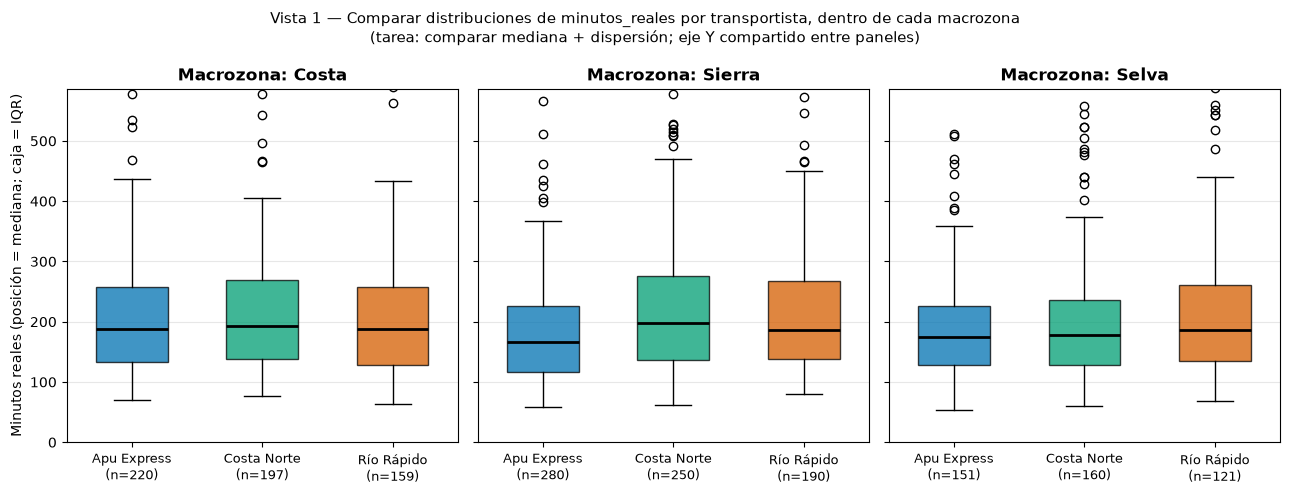

In [9]:
# Figura A — Vista 1: comparar distribuciones de minutos_reales por transportista, faceteado por macrozona
# Tarea analítica: comparar MEDIANA y DISPERSIÓN entre grupos -> box plot (posición = canal más preciso)
macrozonas = ['Costa', 'Sierra', 'Selva']
transportistas = ['Apu Express', 'Costa Norte', 'Río Rápido']
colors = [OKABE_ITO[t] for t in transportistas]

fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
y_max = df['minutos_reales'].quantile(0.99) * 1.05

for ax, mz in zip(axes, macrozonas):
    sub = df[df['macrozona'] == mz]
    data = [sub[sub['transportista'] == t]['minutos_reales'].values for t in transportistas]
    ns = [len(d) for d in data]
    bp = ax.boxplot(data, patch_artist=True, showfliers=True, widths=0.55,
                     medianprops=dict(color='black', linewidth=2))
    ax.set_xticks(range(1, len(transportistas) + 1))
    ax.set_xticklabels([f'{t}\n(n={n})' for t, n in zip(transportistas, ns)])
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_title(f'Macrozona: {mz}', fontsize=12, fontweight='bold')
    ax.set_ylim(0, y_max)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=9)

axes[0].set_ylabel('Minutos reales (posición = mediana; caja = IQR)')
fig.suptitle('Vista 1 — Comparar distribuciones de minutos_reales por transportista, dentro de cada macrozona\n'
             '(tarea: comparar mediana + dispersión; eje Y compartido entre paneles)', fontsize=11)
plt.tight_layout()
plt.show()


In [10]:
# Evidencia para Vista 2: outliers (regla 1.5*IQR) y ecuación de la recta OLS
q1, q3 = df['minutos_reales'].quantile([.25, .75])
iqr = q3 - q1
fence_lo, fence_hi = q1 - 1.5*iqr, q3 + 1.5*iqr
n_outliers = (df['minutos_reales'] > fence_hi).sum()
print(f'Cerca superior IQR minutos_reales: {fence_hi:.1f}  ->  {n_outliers} outliers ({n_outliers/n_total:.1%})')

q1d, q3d = df['distancia_km'].quantile([.25, .75])
iqrd = q3d - q1d
fence_hi_d = q3d + 1.5*iqrd
n_outliers_d = (df['distancia_km'] > fence_hi_d).sum()
print(f'Cerca superior IQR distancia_km: {fence_hi_d:.1f} km  ->  {n_outliers_d} outliers ({n_outliers_d/n_total:.1%})')


Cerca superior IQR minutos_reales: 444.1  ->  62 outliers (3.6%)
Cerca superior IQR distancia_km: 260.8 km  ->  49 outliers (2.8%)


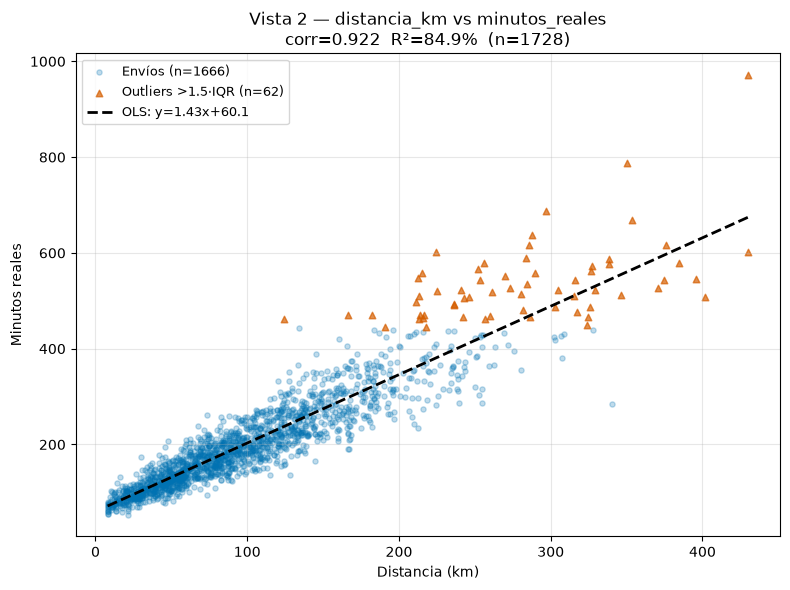

In [11]:
# Figura B — Vista 2: relación distancia_km <-> minutos_reales
# Tarea analítica: evaluar fuerza/forma de correlación -> scatter (posición X-Y, canal más preciso para 2 cuantitativas)
fig, ax = plt.subplots(figsize=(8, 6))

is_outlier = df['minutos_reales'] > fence_hi
ax.scatter(df.loc[~is_outlier, 'distancia_km'], df.loc[~is_outlier, 'minutos_reales'],
           s=14, alpha=0.25, color=OKABE_ITO['Apu Express'], label=f'Envíos (n={(~is_outlier).sum()})')
ax.scatter(df.loc[is_outlier, 'distancia_km'], df.loc[is_outlier, 'minutos_reales'],
           s=22, alpha=0.7, color=OKABE_ITO['Río Rápido'], marker='^',
           label=f'Outliers >1.5·IQR (n={is_outlier.sum()})')

x_line = np.linspace(df['distancia_km'].min(), df['distancia_km'].max(), 100)
ax.plot(x_line, slope_d * x_line + intercept_d, color='black', linewidth=2, linestyle='--',
        label=f'OLS: y={slope_d:.2f}x+{intercept_d:.1f}')

ax.set_xlabel('Distancia (km)')
ax.set_ylabel('Minutos reales')
ax.set_title(f'Vista 2 — distancia_km vs minutos_reales\ncorr={corr_dist:.3f}  R²={corr_dist**2:.1%}  (n={n_total})')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
# Pregunta 2 — La pregunta dicta el gráfico

## Vista 1 — Comparar mediana y dispersión de `minutos_reales` entre transportistas, dentro de cada macrozona

1. **Concepto técnico / tarea analítica declarada:** *comparar distribuciones* (no un solo promedio puntual) entre 3 grupos (transportista) anidados en 3 facetas (macrozona) → marca = **box plot** (posición = mediana y cuartiles; longitud = caja = IQR), que es el estándar para mostrar tendencia central **y** dispersión simultáneamente.
2. **Evidencia con números reales** (celda "Evidencia para Vista 1"): medianas por transportista×macrozona van de 166.1 min (Apu Express–Sierra, n=280) a 197.75 min (Costa Norte–Sierra, n=250); el IQR (dispersión) va de ~97 min (Apu Express–Selva) a ~140 min (Costa Norte–Sierra). El tamaño de cada celda varía de n=121 (Río Rápido–Selva) a n=280 (Apu Express–Sierra).
3. **Decisión de diseño:** eje Y = minutos_reales (**posición**, canal más preciso de la jerarquía posición > longitud > ángulo > área > color); eje X = transportista; **facet por macrozona con eje Y compartido** (mismo rango 0–y_max en los 3 paneles) para permitir comparación directa entre paneles; color de la caja = transportista, **redundante** con la posición en X (no es el único canal de identificación, cumple accesibilidad); mediana marcada con línea negra gruesa; outliers mostrados como puntos (no eliminados).
4. **Límite/trade-off:** el box plot esconde la forma exacta de la distribución (p. ej. bimodalidad) y minimiza la lectura de N si no se anota explícitamente — aquí n varía de 121 a 280 por celda, anotado en las etiquetas del eje X para no sobre-interpretar cajas con pocos datos.

## Vista 2 — Relación `distancia_km` ↔ `minutos_reales`

1. **Concepto técnico / tarea analítica declarada:** *evaluar la fuerza y forma de una relación entre dos variables cuantitativas continuas* → marca = **scatter plot** (posición X-Y, el canal más preciso posible para 2 cuantitativas; muy superior a intentar comprimir esto en líneas/dual-axis como en el gráfico original).
2. **Evidencia con números reales:** corr = **0.922**, R² = **84.9%**; recta OLS *y = 1.43·x + 60.1* (p≈0, n=1728). Tratamiento de outliers: regla 1.5×IQR marca **62 outliers** en minutos_reales (>444.1 min, 3.6%) y **49 outliers** en distancia_km (>260.8 km, 2.8%).
3. **Decisión de diseño:** transparencia (alpha=0.25) para mitigar sobre-trazado (*overplotting*) de 1728 puntos; línea de tendencia OLS anotada con su ecuación y R²; los outliers **no se eliminan** — se resaltan con marcador y color distintos (triángulo vermellón) porque representan casos reales de negocio (p. ej. camiones a distancias largas en Selva) que el gerente necesita ver, no ocultar.
4. **Límite/trade-off:** la recta OLS asume relación lineal y homocedástica; a distancias muy largas la dispersión podría crecer (heterocedasticidad) — antes de usar esta recta para pronóstico habría que revisar residuales por tramo de distancia; además, eliminar outliers "para limpiar el gráfico" sin justificación operativa ocultaría exactamente los envíos que más le cuestan a la operación.

## Elección de KPI principal: tasa de tardanza vs SLA (con P90 como guardrail)

1. **Concepto técnico:** un KPI operacional debe ser **accionable frente a una meta**, no solo descriptivo de una distribución.
2. **Evidencia** (periodo: 18 semanas, `semana_inicio` 2026-03-02 a 2026-06-29): tasa de tardanza agregada = 772/1728 = **44.68%** vs meta 20% (más del doble); P90 por transportista (Apu Express 312.8 min, Costa Norte 354.2 min, Río Rápido 349.9 min) muestra la **cola**; la media (193.8 / 212.8 / 212.3 min) está sesgada por outliers y por la mezcla de distancias; la mediana (175.3 / 187.4 / 187.3 min) es robusta pero esconde justamente esa cola.
3. **Decisión:** recomendar la **tasa de tardanza vs SLA** (`SUM(tardanza_flag)/COUNT(envio_id)`) como KPI decisor primario — es binario, está directamente ligado a la meta operativa del 20% y admite una reference line clara (Pregunta 4); usar **P90** como guardrail de cola, con umbral propuesto **meta P90 ≤ 300 min** (los tres transportistas ya lo superan: 312.8–354.2 min), para detectar si el 10% peor de envíos se dispara aunque la mediana luzca aceptable.
4. **Límite — qué esconde cada estadístico descartado:** la **media** es sensible a outliers y a cambios en el mix de rutas (una semana con más envíos largos la mueve sin que cambie el desempeño real por ruta); la **mediana** esconde la cola (el P90 puede duplicarse sin que la mediana se mueva); la **tasa de tardanza sola** no dice *cuánto* tarde llega un envío (por eso se complementa con P90); ninguna de las cuatro controla por transportista/macrozona por sí sola — deben reportarse siempre segmentadas, no solo en agregado.

**Fórmulas (Tableau + pandas):**
- Mediana por celda: Tableau `{ FIXED [Macrozona],[Transportista] : MEDIAN([Minutos Reales]) }` — pandas `df.groupby(['macrozona','transportista'])['minutos_reales'].median()`
- P90 por transportista: Tableau `{ FIXED [Transportista] : PERCENTILE([Minutos Reales], 0.9) }` (campo calculado con agregación de percentil) — pandas `df.groupby('transportista')['minutos_reales'].quantile(0.9)`
- Tasa de tardanza por transportista: Tableau `SUM([Tardanza Flag]) / COUNT([Envio Id])` con `[Transportista]` en Filas — pandas `df.groupby('transportista')['tardanza_flag'].agg(['sum','count'])` y luego `sum/count`


In [12]:
# Evidencia para Pregunta 3: tasa de tardanza semanal por sede (tabla sede x semana)
wk_pivot = df.pivot_table(index='sede_id', columns='semana_inicio', values='tardanza_flag', aggfunc='mean')
print('Forma de la tabla sede x semana:', wk_pivot.shape)
print(wk_pivot.round(2).iloc[:, :6])  # primeras 6 semanas, muestra

sede_rate_total = df.groupby('sede_id')['tardanza_flag'].agg(tardios='sum', n='count')
sede_rate_total['tasa'] = sede_rate_total['tardios'] / sede_rate_total['n']
sede_rate_total = sede_rate_total.sort_values('tasa', ascending=False)
print('\nTasa de tardanza agregada por sede (18 semanas), ordenada:')
print(sede_rate_total)

focal_sede = sede_rate_total.index[0]
print(f'\nSede focal elegida (peor desempeño agregado): {focal_sede}  tasa={sede_rate_total.loc[focal_sede, "tasa"]:.1%}')


Forma de la tabla sede x semana: (12, 18)
semana_inicio  2026-03-02  2026-03-09  2026-03-16  2026-03-23  2026-03-30  2026-04-06
sede_id                                                                              
SED-01               0.50        0.88        0.88        0.62        0.75        0.50
SED-02               0.62        0.62        0.38        0.38        0.12        0.50
SED-03               0.62        0.38        0.88        0.62        0.50        0.62
SED-04               0.38        0.12        0.38        0.38        0.50        0.38
SED-05               0.88        0.50        0.50        0.50        0.75        0.62
SED-06               0.50        0.62        0.25        0.38        0.50        0.50
SED-07               0.38        0.75        0.38        0.50        0.25        0.38
SED-08               0.50        0.50        0.38        0.25        0.38        0.38
SED-09               0.62        0.38        0.25        0.50        0.25        0.75
SED-10      

In [13]:
# Table calc declarado explícitamente: RANK de sedes por tasa agregada, para ordenar los paneles
# Partición (compute using / addressing): a lo largo de [Sede_id], sin restart -> una sola partición (toda la tabla)
# Adición: ranking descendente por tasa (empates -> 'competition' / rank denso)
sede_rate_total['rank_sede'] = sede_rate_total['tasa'].rank(ascending=False, method='min').astype(int)
print(sede_rate_total[['tasa', 'rank_sede']])
print('\nTableau: RANK(SUM([Tardanza_flag])/COUNT([Envio_id])) con Partición=ninguna (toda la tabla), '
      'Addressing=[Sede_id] -> ordena los 12 paneles de peor a mejor.')


             tasa  rank_sede
sede_id                     
SED-01   0.611111          1
SED-05   0.604167          2
SED-03   0.548611          3
SED-10   0.465278          4
SED-06   0.444444          5
SED-11   0.430556          6
SED-12   0.416667          7
SED-08   0.409722          8
SED-07   0.402778          9
SED-02   0.381944         10
SED-09   0.361111         11
SED-04   0.284722         12

Tableau: RANK(SUM([Tardanza_flag])/COUNT([Envio_id])) con Partición=ninguna (toda la tabla), Addressing=[Sede_id] -> ordena los 12 paneles de peor a mejor.


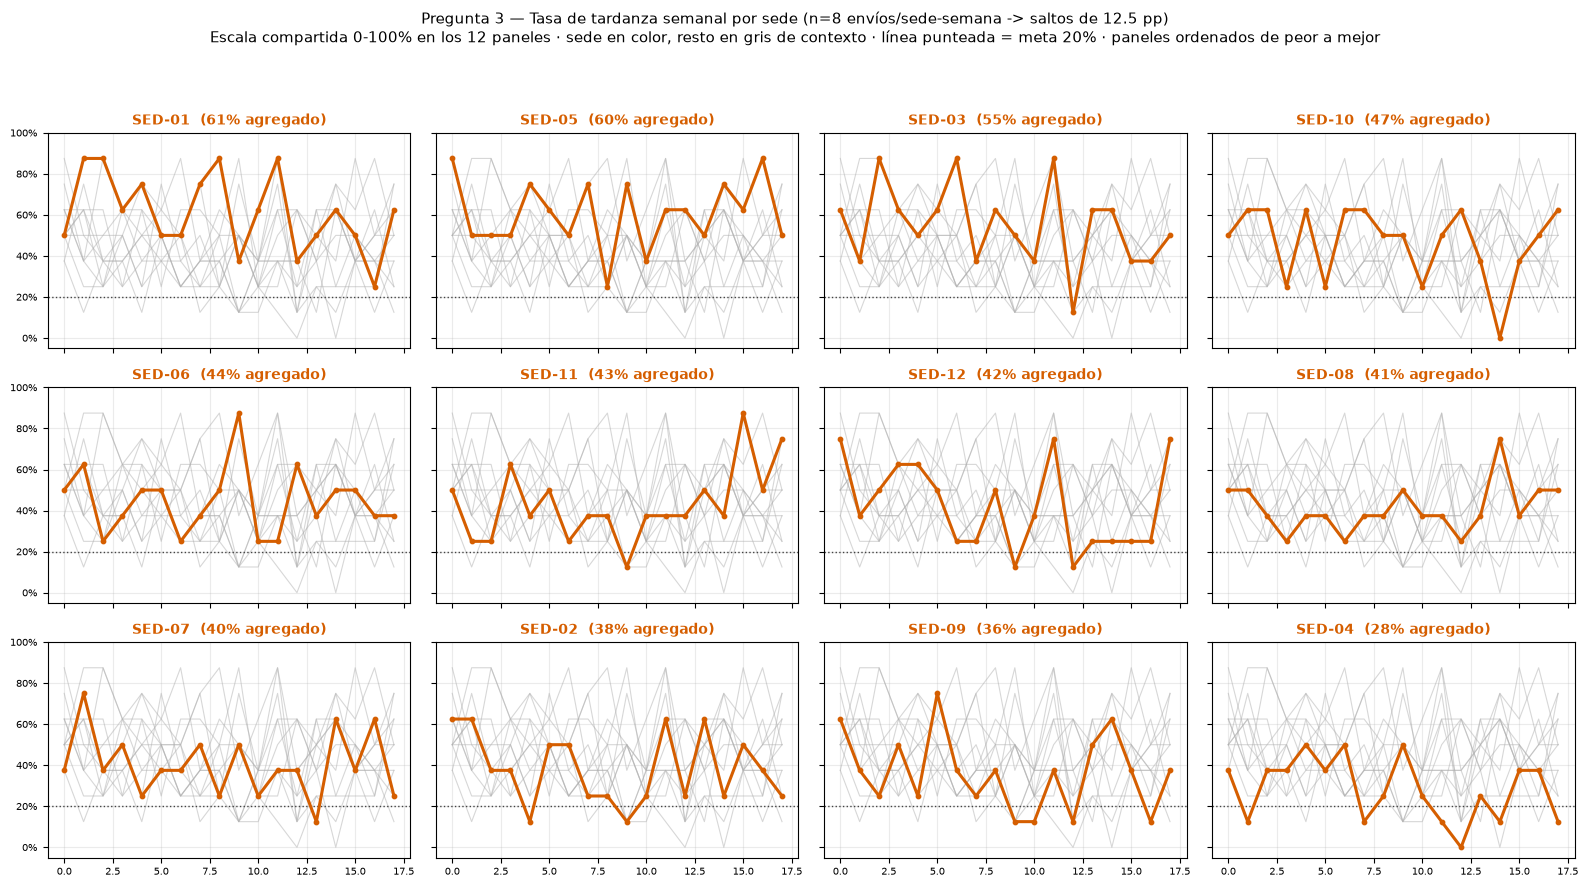

In [14]:
# Figura C — Pequeños múltiplos: evolución semanal de tasa de tardanza por sede (12 paneles)
# Escala COMPARTIDA 0-100% en todos los paneles; sede propia en color, resto en gris de contexto;
# etiqueta directa (texto), sin leyenda de 12 colores; línea de referencia = meta 20%.
sede_order = sede_rate_total.index.tolist()  # ordenado por tasa agregada (peor a mejor)
semanas = sorted(df['semana_inicio'].unique())
x = np.arange(len(semanas))

fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i, sede in enumerate(sede_order):
    ax = axes[i]
    # contexto: las otras 11 sedes en gris tenue
    for otra in sede_order:
        if otra == sede:
            continue
        serie_otra = wk_pivot.loc[otra, semanas].values
        ax.plot(x, serie_otra, color=OKABE_ITO['contexto'], alpha=0.5, linewidth=0.8, zorder=1)
    # foco: la sede del panel, resaltada
    serie = wk_pivot.loc[sede, semanas].values
    ax.plot(x, serie, color=OKABE_ITO['focal'], linewidth=2.2, zorder=3)
    ax.scatter(x, serie, color=OKABE_ITO['focal'], s=10, zorder=3)
    # reference line: meta 20%
    ax.axhline(0.20, color=OKABE_ITO['meta'], linewidth=1, linestyle=':', zorder=2)
    ax.set_ylim(-0.05, 1.0)
    tasa_agg = sede_rate_total.loc[sede, 'tasa']
    ax.set_title(f'{sede}  ({tasa_agg:.0%} agregado)', fontsize=10, fontweight='bold', color=OKABE_ITO['focal'])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.grid(alpha=0.25)
    ax.tick_params(labelsize=7)

fig.suptitle('Pregunta 3 — Tasa de tardanza semanal por sede (n=8 envíos/sede-semana -> saltos de 12.5 pp)\n'
             'Escala compartida 0-100% en los 12 paneles · sede en color, resto en gris de contexto · '
             'línea punteada = meta 20% · paneles ordenados de peor a mejor', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


---
# Pregunta 3 — Doce series sin espagueti

**Tarea analítica declarada:** seguir la *evolución semanal de la tasa de tardanza por sede* para detectar cuáles sedes están sistemáticamente por encima de la meta, sin perder la capacidad de comparar magnitudes entre sedes.

1. **Concepto técnico:** con 12 series de solo 18 puntos cada una y ruido alto (ver punto 2), superponerlas en un único plano es un antipatrón de selección de gráfico. La solución es **pequeños múltiplos** (facet por sede) **combinado con foco+contexto** (la sede de cada panel resaltada en color, las otras 11 dibujadas en gris de fondo como referencia) — así se preserva tanto la comparación "dentro de panel vs meta" como la comparación "entre sedes" sin espagueti ni leyenda de 12 colores.
2. **Evidencia con números reales:** 12 sedes × 18 semanas = 216 celdas sede-semana, cada una con **exactamente 8 envíos** (min=mediana=max=8), por lo que la tasa semanal de una sede solo puede tomar valores en **incrementos de 12.5 puntos porcentuales** (0%, 12.5%, …, 87.5%): un solo envío que cruza el umbral mueve la tasa 12.5 pp de golpe. Con 8 envíos/sede-semana × 18 semanas = 144 envíos por sede, la sede con peor tasa agregada es **SED-01 (Lima, Costa) con 61.1% = 88/144**; la mejor es **SED-04 (Chiclayo, Costa) con 28.5% = 41/144** (ver tabla de la celda anterior).
3. **Decisión de diseño (comparabilidad):**
   - **Escala compartida 0–100%** en los 12 paneles (nunca autoescalada) — condición no negociable para que la altura de cada línea sea comparable entre paneles.
   - **Etiquetado directo**: el nombre de la sede y su tasa agregada se imprimen como título del panel (texto), no hay leyenda de color para 12 series.
   - **Supervivencia a daltonismo/escala de grises:** el significado no depende del matiz — depende de la **posición** de la línea coloreada respecto a la línea de referencia (meta 20%, línea punteada) y de la **etiqueta de texto** directa; en escala de grises, la línea focal (más gruesa, con marcadores) sigue siendo distinguible del fondo gris tenue por **grosor y opacidad**, no solo color.
   - **Reference line de meta (20%)** repetida en cada panel para juicio inmediato de "por encima/por debajo".
4. **Límite/trade-off — el peligro de autoescalar:** si cada panel usara su **propio eje Y** ajustado al rango local de esa sede, una sede de bajo desempeño real (ej. SED-04, 28.5% agregado, con variación semana a semana pequeña en términos absolutos) podría verse tan "dramática" en su panel como SED-01 (61.1%) — porque el eje se estira para llenar el espacio del panel. Esto es una **ilusión creada por el diseño (autoescalado), no por la magnitud real de los datos** — motivo exacto por el que se fija la escala compartida 0–100%. Además, con n=8/semana, **un solo pico de una semana aislada no debe leerse como tendencia**: se recomienda no interpretar un salto de 12.5 pp sin mirar al menos 3-4 semanas consecutivas o el agregado del panel.

**Table calc declarado (partición + addressing):** el ranking de paneles usa `RANK(SUM([Tardanza_flag])/COUNT([Envio_id]))` con **Partición = ninguna (toda la tabla es una sola partición)** y **Addressing = [Sede_id]** (recorre las 12 sedes, sin reinicio) — de ahí el orden de peor a mejor en la figura.


In [15]:
# Evidencia adicional para Pregunta 4: mecanismo lluvia -> tardanza_flag, y chequeo de confusores
print('== Medias de minutos_reales por lluvia_flag ==')
print(df.groupby('lluvia_flag')['minutos_reales'].mean().round(1))

print('\n== Tasa de tardanza (naive, sin controlar nada) por lluvia_flag ==')
naive = df.groupby('lluvia_flag')['tardanza_flag'].agg(tardios='sum', n='count')
naive['tasa'] = naive['tardios'] / naive['n']
print(naive)

print('\n== Chequeo de confusores: ¿el mix de transportista/vehículo/macrozona cambia con lluvia_flag? ==')
print('Transportista (proporción dentro de cada grupo de lluvia):')
print(pd.crosstab(df['transportista'], df['lluvia_flag'], normalize='columns').round(3))
print('\nVehículo:')
print(pd.crosstab(df['vehiculo'], df['lluvia_flag'], normalize='columns').round(3))
print('\n-> transportista y vehículo están BALANCEADOS entre lluvia_flag=0/1 (no son confusores fuertes aquí).')

print('\nIncidencia de lluvia por macrozona (SÍ varía -> macrozona es un confusor de la EXPOSICIÓN):')
lluvia_macro = df.groupby('macrozona')['lluvia_flag'].agg(con_lluvia='sum', n='count')
lluvia_macro['tasa'] = lluvia_macro['con_lluvia'] / lluvia_macro['n']
print(lluvia_macro.round(3).sort_values('tasa', ascending=False))
print('Pero la tasa de tardanza por macrozona es casi plana:')
tardanza_macro = df.groupby('macrozona')['tardanza_flag'].agg(tardios='sum', n='count')
tardanza_macro['tasa'] = tardanza_macro['tardios'] / tardanza_macro['n']
print(tardanza_macro.round(3).sort_values('tasa', ascending=False))


== Medias de minutos_reales por lluvia_flag ==
lluvia_flag
0    197.0
1    228.3
Name: minutos_reales, dtype: float64

== Tasa de tardanza (naive, sin controlar nada) por lluvia_flag ==
             tardios     n      tasa
lluvia_flag                         
0                411  1256  0.327229
1                361   472  0.764831

== Chequeo de confusores: ¿el mix de transportista/vehículo/macrozona cambia con lluvia_flag? ==
Transportista (proporción dentro de cada grupo de lluvia):
lluvia_flag        0      1
transportista              
Apu Express    0.377  0.375
Costa Norte    0.347  0.362
Río Rápido     0.275  0.263

Vehículo:
lluvia_flag      0      1
vehiculo                 
Camión       0.319  0.347
Moto         0.197  0.180
Van          0.484  0.472

-> transportista y vehículo están BALANCEADOS entre lluvia_flag=0/1 (no son confusores fuertes aquí).

Incidencia de lluvia por macrozona (SÍ varía -> macrozona es un confusor de la EXPOSICIÓN):
           con_lluvia    n   tas

In [16]:
# Estratificación por tercil de distancia: ¿persiste la asociación lluvia-tardanza controlando distancia?
df['dist_tercil'] = pd.qcut(df['distancia_km'], 3, labels=['Corta', 'Media', 'Larga'])
estrat = df.groupby(['dist_tercil', 'lluvia_flag'], observed=True)['tardanza_flag'].mean().unstack()
estrat.columns = ['sin_lluvia', 'con_lluvia']
estrat['brecha_pp'] = (estrat['con_lluvia'] - estrat['sin_lluvia']) * 100
print(estrat.round(3))
print('\n-> La brecha lluvia (con - sin) persiste y es grande (~38-48 pp) en los TRES terciles de distancia:')
print('   la asociación lluvia->tardanza_flag no se explica solo por distancia (que es independiente de lluvia_mm, corr=0.001).')
print('   Sigue siendo asociación observacional: faltan controles por transportista/vehículo/semana y factores no medidos (tráfico, hora).')


             sin_lluvia  con_lluvia  brecha_pp
dist_tercil                                   
Corta             0.337       0.715     37.787
Media             0.316       0.775     45.897
Larga             0.328       0.807     47.899

-> La brecha lluvia (con - sin) persiste y es grande (~38-48 pp) en los TRES terciles de distancia:
   la asociación lluvia->tardanza_flag no se explica solo por distancia (que es independiente de lluvia_mm, corr=0.001).
   Sigue siendo asociación observacional: faltan controles por transportista/vehículo/semana y factores no medidos (tráfico, hora).


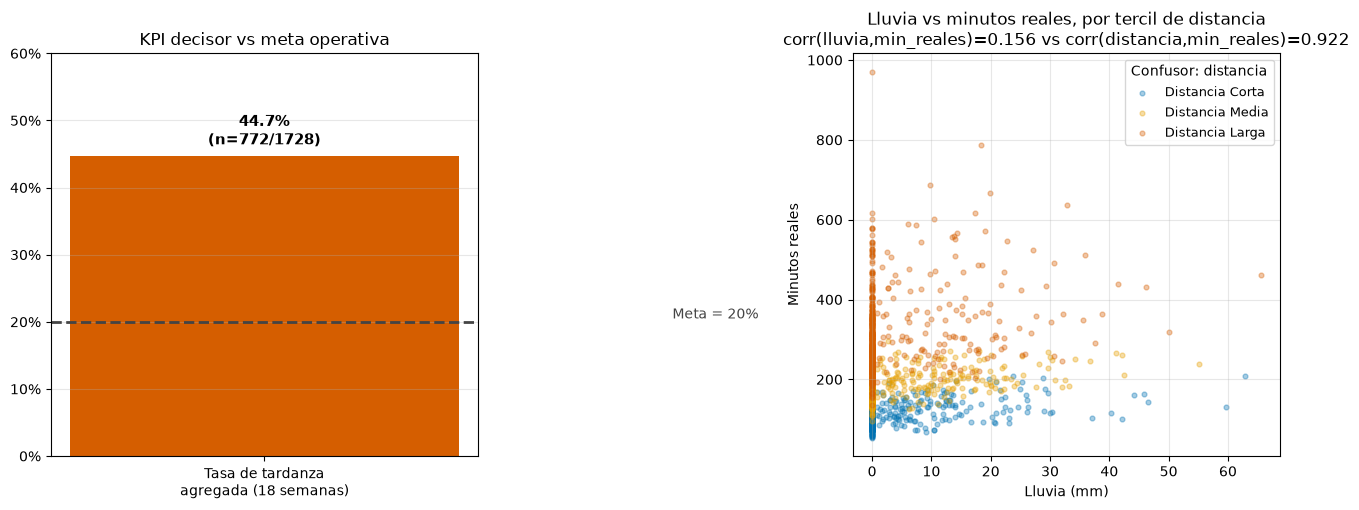

In [17]:
# Figura D — (izq) KPI decisor vs meta; (der) lluvia_mm vs minutos_reales coloreada por tercil de distancia (chequeo visual de confusión)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# Panel izquierdo: tasa de tardanza agregada vs meta 20%
ax = axes[0]
ax.bar(['Tasa de tardanza\nagregada (18 semanas)'], [tasa_tardanza_agregada], color=OKABE_ITO['Río Rápido'], width=0.5)
ax.axhline(0.20, color=OKABE_ITO['meta'], linestyle='--', linewidth=2)
ax.text(0.52, 0.20, ' Meta = 20%', va='bottom', ha='left', color=OKABE_ITO['meta'], fontsize=10)
ax.text(0, tasa_tardanza_agregada + 0.01, f'{tasa_tardanza_agregada:.1%}\n(n={n_tarde}/{n_total})',
        ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 0.6)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('KPI decisor vs meta operativa')
ax.grid(axis='y', alpha=0.3)

# Panel derecho: lluvia_mm vs minutos_reales, coloreado por tercil de distancia
ax = axes[1]
tercil_colors = {'Corta': '#0072B2', 'Media': '#E69F00', 'Larga': '#D55E00'}
for terc, c in tercil_colors.items():
    sub = df[df['dist_tercil'] == terc]
    ax.scatter(sub['lluvia_mm'], sub['minutos_reales'], s=12, alpha=0.35, color=c, label=f'Distancia {terc}')
ax.set_xlabel('Lluvia (mm)')
ax.set_ylabel('Minutos reales')
ax.set_title(f'Lluvia vs minutos reales, por tercil de distancia\ncorr(lluvia,min_reales)={corr_lluvia:.3f} vs corr(distancia,min_reales)={corr_dist:.3f}')
ax.legend(fontsize=9, title='Confusor: distancia')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
# Pregunta 4 — Declarar no es inferir

## KPI decisor: tasa de tardanza agregada vs meta

1. **Concepto técnico:** una **reference line** de meta convierte una tasa descriptiva en un juicio operativo binario (¿cruza o no cruza la meta?) — no es un promedio ilustrativo, es un umbral de decisión.
2. **Evidencia con números reales:** `num` = envíos con `tardanza_flag=1` = **772**; `den` = envíos totales = **1728**; **tasa de tardanza agregada = 772/1728 = 44.68%**. Periodo: 18 semanas, `semana_inicio` 2026-03-02 a 2026-06-29. Segmento: agregado, todas las sedes/transportistas. Meta operativa declarada: **20%**. El KPI está **24.68 puntos porcentuales por encima de la meta** (2.23× la meta).
3. **Decisión:** dibujar una **reference line horizontal en 20%** sobre la serie/barra de tasa de tardanza (ver Figura D, panel izquierdo) y reportar siempre `num/den` junto al porcentaje — nunca el porcentaje solo. Fórmula Tableau: `SUM([Tardanza_flag]) / COUNT([Envio_id])`, con reference line constante en `0.20` (campo calculado `Meta = 0.20` o parámetro). Pandas: `df['tardanza_flag'].sum() / len(df)`.
4. **Límite:** la tasa agregada mezcla transportistas muy distintos (Apu Express 32.4% = 211/651 vs Río Rápido 57.2% = 269/470) y sedes muy distintas (SED-04 28.5% = 41/144 – SED-01 61.1% = 88/144) — cruzar la meta en agregado no dice **dónde** actuar; siempre debe acompañarse de la vista segmentada (Pregunta 2/3) antes de tomar una decisión de asignación.

## Trend line lluvia↔demora: pregunta distinta, no causal

1. **Concepto técnico:** una trend line (OLS) entre `lluvia_mm` y `minutos_reales` responde a la pregunta **"¿cuál es la mejor recta lineal que resume cómo covarían estas dos variables en los datos observados?"** — una pregunta **descriptiva/asociativa** (¿cuánto se mueve Y en promedio por unidad de X, en esta muestra?), **no** la pregunta causal **"¿si yo pudiera cambiar la lluvia (manteniendo todo lo demás fijo), cambiaría el tiempo de entrega?"** Esta segunda pregunta requiere un diseño que aísle la lluvia de sus co-variables (experimento o cuasi-experimento), algo que un CSV observacional de un período no ofrece.
2. **Evidencia:** OLS lluvia→minutos_reales: *y = 2.01·lluvia_mm + 198.2* (r=0.156, R²=2.4%, p=6.8e-11 — significativo pero de **efecto pequeño** sobre los minutos crudos). Sin embargo, sobre `tardanza_flag` la asociación naive es mayor: 32.7% = 411/1256 (sin lluvia) vs 76.5% = 361/472 (con lluvia), y esa brecha de ~38-48 puntos porcentuales **persiste dentro de cada tercil de distancia** (corta/media/larga) — ver celda de estratificación arriba. Transportista y vehículo están balanceados entre lluvia=0/1 (no son confusores fuertes de la exposición); macrozona sí varía en incidencia de lluvia (Selva 41.7% = 180/432 vs Costa 16.5% = 95/576) pero su tasa de tardanza propia es casi plana (43.7%-45.7%, es decir Selva 189/432 a Costa 263/576), por lo que tampoco explica la brecha por sí sola.
3. **Supuestos que revisaría antes de confiar en la trend line:**
   - **Linealidad:** ¿el efecto de la lluvia es realmente lineal en mm, o hay un umbral (p. ej. "llueve o no llueve" importa más que los mm exactos)? El salto grande en `tardanza_flag` vs el R² bajo en minutos crudos sugiere que el mecanismo real puede ser un efecto de umbral sobre el *ratio* minutos_reales/objetivo (corr(lluvia_mm, ratio)=0.489, mucho mayor que corr(lluvia_mm, minutos_reales)=0.156), no una recta continua.
   - **Confusores:** distancia (r=0.922 con el resultado, pero r=0.001 con lluvia → no es confusor clásico de la relación lluvia-minutos, aunque sí domina la varianza total); transportista y vehículo (balanceados, chequeado arriba); macrozona (asociada a la exposición, tasa de tardanza propia casi plana); **factores no medidos** (tráfico, hora del día, prioridad de envío, día de semana) que podrían co-variar con la lluvia y explicar parte de la brecha.
4. **Por qué ni una pendiente ni un buen R² demuestran causalidad:** los datos son **observacionales** (nadie asignó aleatoriamente qué envíos "reciben" lluvia); un R² alto solo certifica buen ajuste dentro de la muestra, no aislamiento de la causa. Aquí, además, el R² de lluvia sobre minutos crudos es **bajo** (2.4%) precisamente porque distancia domina la varianza (85%) — mezclar ambas señales en un gráfico de doble eje, como hacía el original, es lo que producía la ilusión de "prueba científica".

## BITÁCORA (5 frases)

1. **Lectura inicial (≤15 palabras):** "La lluvia parece causar toda la tardanza; el gráfico de 12 líneas lo prueba."
2. **KPI decisor:** Tasa de tardanza vs SLA — Tableau `SUM([Tardanza_flag])/COUNT([Envio_id])`, pandas `df['tardanza_flag'].sum()/len(df)` — periodo 2026-03-02 a 2026-06-29 (18 semanas) — segmento agregado y por transportista/sede — meta 20%.
3. **Giro analítico:** al descomponer por distancia y transportista, distancia explica 84.9% de la varianza de minutos_reales (r=0.922) frente a 2.4% de la lluvia (r=0.156); Río Rápido (57.2% = 269/470 tardíos) casi duplica a Apu Express (32.4% = 211/651) — el problema es mayormente operativo (ruteo/transportista), no meteorológico, aunque la lluvia sigue asociada al incumplimiento de SLA dentro de cada tercil de distancia.
4. **Lectura revisada (≤15 palabras):** "Distancia y transportista se asocian con la tardanza; la lluvia es secundaria pero no nula."
5. **Consecuencia:** la decisión que cambia es priorizar la renegociación de rutas/SLA con Río Rápido y Costa Norte y revisar la asignación en distancias largas, en vez de invertir primero en "gestión de lluvia"; el dato que **refutaría** esta lectura revisada sería una regresión múltiple (lluvia_flag + distancia_km + transportista + vehículo + macrozona + semana) donde el coeficiente de lluvia_flag **deje de ser significativo** tras controlar todo lo demás, o —mejor aún— un experimento/cuasi-experimento que compare la misma ruta/transportista/vehículo en semanas de lluvia vs sin lluvia y muestre que la tardanza no cambia; si en cambio el coeficiente de lluvia se mantiene significativo y sizable tras esos controles, habría que reincorporar la lluvia como factor operativo real (no como "prueba científica" única, sino como covariable relevante junto a distancia y transportista).


## Resumen visual — dónde y cuándo se concentra la tardanza
El color reemplaza doce relatos separados: las celdas oscuras señalan semanas que requieren atención.

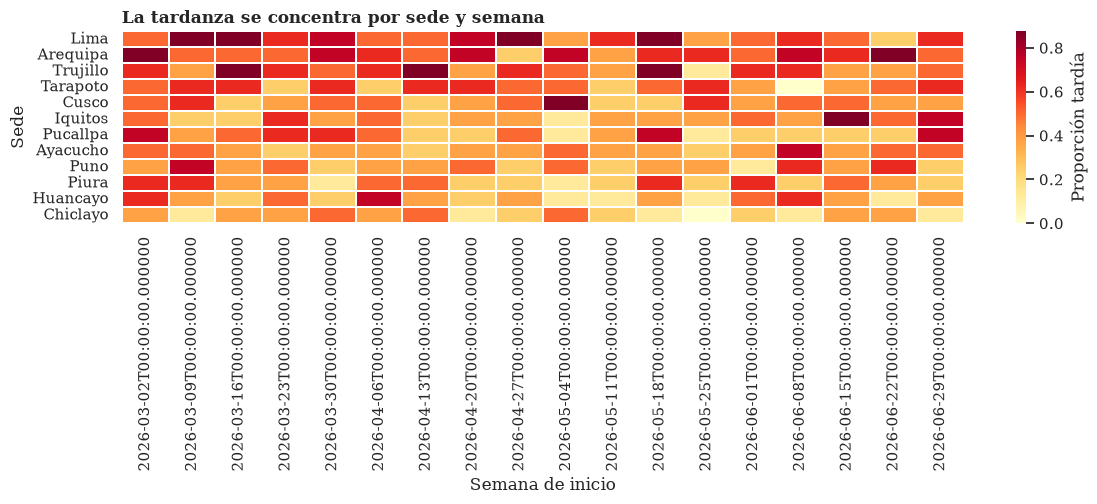

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
d = pd.read_csv('../data/caso2_logistica_chasquifest.csv', parse_dates=['semana_inicio'])
h = d.pivot_table(index='ciudad', columns='semana_inicio', values='tardanza_flag', aggfunc='mean')
h = h.loc[d.groupby('ciudad')['tardanza_flag'].mean().sort_values(ascending=False).index]
sns.set_theme(style='white', font='serif')
fig, ax = plt.subplots(figsize=(12, 5.2))
sns.heatmap(h, cmap='YlOrRd', vmin=0, vmax=max(.5, np.nanmax(h.values)), cbar_kws={'label': 'Proporción tardía'}, linewidths=.25, ax=ax)
ax.set_title('La tardanza se concentra por sede y semana', loc='left', fontweight='bold')
ax.set_xlabel('Semana de inicio'); ax.set_ylabel('Sede')
plt.tight_layout(); plt.savefig('fig4_mapa_calor_tardanza.png', dpi=130, bbox_inches='tight'); plt.show()
